## Notebook for core functions of NPMI based 3D cell graph pruning
## Long Yuan 
## Version 10-22-2025
## lyuan13@jhmi.edu

In [ ]:
from spatialdata_io import xenium
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch_geometric.data import Data
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from mpl_toolkits.mplot3d import Axes3D  

In [ ]:
# --- Read in the data and perfrom basic qc ---
sdata = xenium(r"20241004__181016__Q044_GBM2_23274_23073_BT4OCT24\output-XETG00323__0023274__P4_resection__20241004__181038")
transcripts_df = sdata.points["transcripts"].compute()
filtered_df = transcripts_df[transcripts_df["qv"] >= 30]
filtered_df = filtered_df[filtered_df["is_gene"] == True]

In [ ]:
# --- Find cell id of interest based on marker gene expression ---
points = filtered_df[filtered_df["feature_name"] == "CD163"]

# Count how many are UNASSIGNED vs assigned
points["cell_id"].value_counts().head(10)

cell_id
UNASSIGNED    91450
djcjhfcd-1       60
ekpaoiep-1       50
cgkmiegp-1       49
ambgcccd-1       48
apjhdogk-1       44
aefpdafk-1       42
emaiafhc-1       41
aehjfegh-1       41
mpjjbbni-1       41
Name: count, dtype: int64[pyarrow]

In [ ]:
# --- Get bounding box of the cell ---
# Access the cell boundaries GeoDataFrame
cell_gdf = sdata.shapes["cell_boundaries"]

# Select the cell of interest
#cell_id = "cknejboe-1"
cell_id = "djcjhfcd-1"
cell_row = cell_gdf.loc[[cell_id]]

# Get its geometry
cell_geom = cell_row.geometry.iloc[0]

# Compute its bounding box
bbox = cell_geom.bounds  # (minx, miny, maxx, maxy)
bbox

(3421.675048828125, 1729.53759765625, 3442.5, 1740.5875244140625)

In [ ]:
# --- Get ROI of the cell of interest ---
roi_df = filtered_df[
    (filtered_df["x"] >= 3400) & (filtered_df["x"] <= 3450) &
    (filtered_df["y"] >= 1700) & (filtered_df["y"] <= 1750)
].reset_index(drop=True)

print(roi_df.shape)
roi_df.head()

(8696, 13)


,x,y,z,feature_name,cell_id,codeword_category,overlaps_nucleus,transcript_id,qv,nucleus_distance,codeword_index,fov_name,is_gene
0,3419.578125,1739.062500,20.421875,ABCC9,dgnkncjk-1,predesigned_gene,0,281822869444373,37.75,4.65625,342,X7,True
1,3425.984375,1744.640625,19.859375,ABCC9,dgnkncjk-1,predesigned_gene,0,281822869445228,37.75,0.43750,342,X7,True
2,3426.312500,1743.734375,19.921875,ABCC9,dgnkncjk-1,predesigned_gene,1,281822869445263,38.25,0.00000,342,X7,True
3,3424.187500,1743.875000,20.718750,ABCC9,dgnkncjk-1,predesigned_gene,0,281822869582687,39.50,0.75000,342,X7,True
4,3421.734375,1738.734375,20.562500,ABCC9,dgnkncjk-1,predesigned_gene,0,281822870255924,40.00,3.03125,342,X7,True


In [6]:
np.unique(roi_df.cell_id)

array(['UNASSIGNED', 'dgngjepi-1', 'dgninjep-1', 'dgnkaclh-1',
       'dgnkncjk-1', 'dgnmjpoh-1', 'dgnmlohl-1', 'dgnnjhhc-1',
       'dgnpllmf-1', 'djcjciai-1', 'djcjhfcd-1', 'djckcelp-1',
       'djckldfg-1', 'djckpagf-1'], dtype=object)

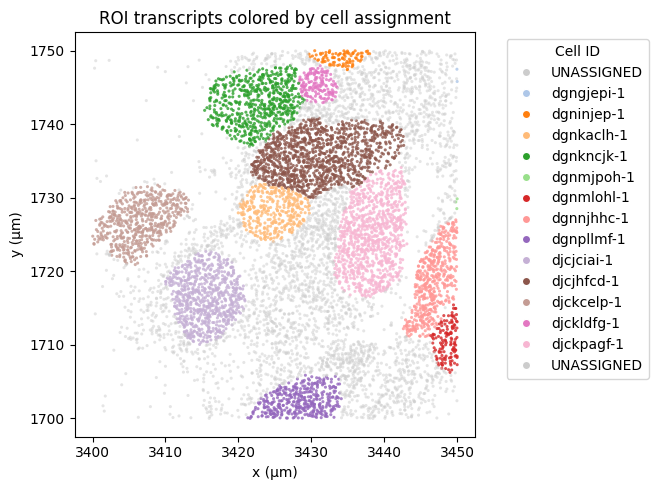

In [ ]:
# --- Visulize transcript nodes colored by cell ID ---
unique_cells = sorted(roi_df['cell_id'].dropna().unique().tolist())

# Assign colors 
palette = sns.color_palette("tab20", n_colors=len(unique_cells))

# Make a mapping, default to light gray for unassigned
color_map = {cid: c for cid, c in zip(unique_cells, palette)}
color_map["UNASSIGNED"] = (0.8, 0.8, 0.8) 
plt.figure(figsize=(7.5,5))

# Split assigned vs unassigned 
assigned = roi_df[roi_df['cell_id'] != "UNASSIGNED"]
unassigned = roi_df[roi_df['cell_id'] == "UNASSIGNED"]

# Plot assigned
plt.scatter(
    assigned['x'], assigned['y'],
    c=assigned['cell_id'].map(color_map),
    s=5, alpha=0.8, linewidths=0
)

# Plot unassigned
plt.scatter(
    unassigned['x'], unassigned['y'],
    c=[color_map["UNASSIGNED"]] * len(unassigned),
    s=5, alpha=0.5, linewidths=0
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=cid, markerfacecolor=color_map[cid],
           markersize=6)
    for cid in unique_cells[:20]  # show first 20
]
legend_elements.append(
    Line2D([0], [0], marker='o', color='w',
           label='UNASSIGNED', markerfacecolor=color_map["UNASSIGNED"],
           markersize=6)
)

plt.legend(
    handles=legend_elements,
    title="Cell ID",
    loc="upper right",
    bbox_to_anchor=(1.45, 1)
)

plt.gca()
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.title("ROI transcripts colored by cell assignment")
plt.tight_layout()
plt.show()

In [ ]:
##########################################
## Functions for 3D graph constructions ##
##########################################
def compute_edge_distances(pos, edge_index):
    src = edge_index[0]
    tgt = edge_index[1]
    distances = np.linalg.norm(pos[src] - pos[tgt], axis=1)
    return distances

def compute_node_degrees(edge_index, num_nodes):
    edge_u = edge_index[0]
    edge_v = edge_index[1]
    edges = np.vstack([edge_u, edge_v]).T
    undirected_edges = set(tuple(sorted(edge)) for edge in edges)
    degree_counts = Counter()
    for u, v in undirected_edges:
        degree_counts[u] += 1
        degree_counts[v] += 1
    degree_array = np.zeros(num_nodes, dtype=int)
    for node, deg in degree_counts.items():
        degree_array[node] = deg
    return degree_array

def get_graph_3dknn(df, k=10, dist_thres=10.0, same_nucleus_only=False):
    # --- Extract coordinates and features ---
    coords = df[['x', 'y', 'z']].to_numpy()
    in_nucleus = df["overlaps_nucleus"].values
    gene_names = df['feature_name'].astype(str).values
    cell_ids = df['cell_id'].astype(str).values if 'cell_id' in df.columns else np.array(["UNASSIGNED"]*len(df))
    n_roi = coords.shape[0]

    # --- kNN search ---
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # --- Build edge list ---
    edge_list = []
    for i in range(n_roi):
        for dist, j in zip(distances[i][1:], indices[i][1:]):  # skip self
            if dist <= dist_thres and gene_names[i] != gene_names[j]:
                edge_list.append((i, j))

    # --- Restrict to within-nucleus edges if requested ---
    if same_nucleus_only and 'cell_id' in df.columns:
        edge_list = [(u, v) for (u, v) in edge_list if cell_ids[u] == cell_ids[v]]

    # --- Compute node degree ---
    node_degree = Counter()
    for u, v in edge_list:
        node_degree[u] += 1
        node_degree[v] += 1

    valid_nodes = np.array([n for n in range(n_roi) if node_degree[n] > 0])
    keep_mask = np.zeros(n_roi, dtype=bool)
    keep_mask[valid_nodes] = True

    # --- Filter dataframe and recompute ---
    df = df.loc[keep_mask].reset_index(drop=True)
    coords = df[['x', 'y', 'z']].to_numpy()
    gene_names = df['feature_name'].astype(str).values
    cell_ids = df['cell_id'].astype(str).values if 'cell_id' in df.columns else np.array(["UNASSIGNED"]*len(df))
    in_nucleus = df["overlaps_nucleus"].values  # <-- update here
    n_nodes = coords.shape[0]

    # --- Reindex edges ---
    old_to_new = {old_idx: new_idx for new_idx, old_idx in enumerate(valid_nodes)}
    reindexed_edges = [(old_to_new[u], old_to_new[v]) for (u, v) in edge_list if u in old_to_new and v in old_to_new]
    edge_index = torch.tensor(reindexed_edges, dtype=torch.long).t().contiguous()

    # --- Compute edge attributes ---
    distance = compute_edge_distances(coords, edge_index.numpy())
    node_degrees = compute_node_degrees(edge_index.numpy(), n_nodes)
    node1_degree = node_degrees[edge_index[0].numpy()]
    node2_degree = node_degrees[edge_index[1].numpy()]

    # --- Encode cell IDs ---
    unique_ids = sorted(set(cell_ids) - {"UNASSIGNED"})
    id_to_int = {cid: i for i, cid in enumerate(unique_ids)}
    cell_id_encoded = np.array([id_to_int.get(cid, -1) for cid in cell_ids], dtype=np.int32)

    # --- Package into PyG Data object ---
    data = Data(
        edge_index=edge_index,
        pos=torch.tensor(coords, dtype=torch.float),
        gene_name=gene_names.tolist(),
        cell_id=torch.tensor(cell_id_encoded, dtype=torch.long),
        distance=torch.tensor(distance, dtype=torch.float),
        nuclear=torch.tensor(in_nucleus, dtype=torch.int64),
        node1_degree=torch.tensor(node1_degree, dtype=torch.long),
        node2_degree=torch.tensor(node2_degree, dtype=torch.long)
    )

    return data, df

In [ ]:
# --- Construct 3D kNN graph ---
data3, df3 = get_graph_3dknn(roi_df, k=100, dist_thres=1.5)
data3

Data(edge_index=[2, 140212], pos=[8653, 3], gene_name=[8653], cell_id=[8653], distance=[140212], nuclear=[8653], node1_degree=[140212], node2_degree=[140212])

Cell djcjhfcd-1 has 1099 transcripts
Edges inside cell djcjhfcd-1: 21660


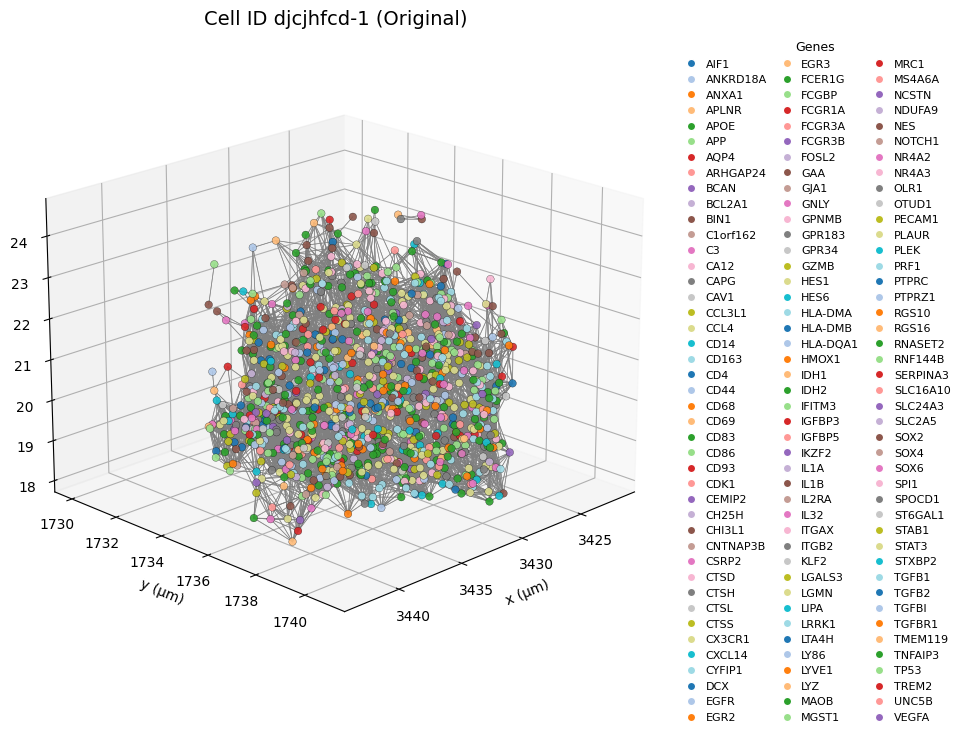

In [ ]:
# --- Visualize 3D graph of the cell ---
#cell_id_target = 'cknejboe-1'
cell_id_target = 'djcjhfcd-1'

# Find node indices for this cell
nodes_in_cell = np.where(df3["cell_id"] == cell_id_target)[0]
print(f"Cell {cell_id_target} has {len(nodes_in_cell)} transcripts")

# Subset positions and genes
pos = data3.pos[nodes_in_cell].numpy()
genes = np.array([data3.gene_name[i] for i in nodes_in_cell])
edge_index = data3.edge_index.numpy()

# Keep only edges where both nodes are within this cell
mask_edges = np.isin(edge_index[0], nodes_in_cell) & np.isin(edge_index[1], nodes_in_cell)
edges_in_cell = edge_index[:, mask_edges]
print(f"Edges inside cell {cell_id_target}: {edges_in_cell.shape[1]}")

unique_genes = np.unique(genes)
palette = sns.color_palette("tab20", n_colors=len(unique_genes))
gene_color_map = {g: c for g, c in zip(unique_genes, palette)}
colors = np.array([gene_color_map[g] for g in genes])

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Plot edges 
for u, v in edges_in_cell.T:
    if u in nodes_in_cell and v in nodes_in_cell:
        idx_u = np.where(nodes_in_cell == u)[0][0]
        idx_v = np.where(nodes_in_cell == v)[0][0]
        ax.plot(
            [pos[idx_u, 0], pos[idx_v, 0]],
            [pos[idx_u, 1], pos[idx_v, 1]],
            [pos[idx_u, 2], pos[idx_v, 2]],
            color="gray", alpha=0.8, linewidth=0.5
        )

# Plot transcripts 
ax.scatter(
    pos[:, 0], pos[:, 1], pos[:, 2],
    c=colors, s=30, alpha=0.9, edgecolor="k", linewidth=0.2
)

ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_zlabel("z (µm)")
ax.set_title(f"Cell ID {cell_id_target} (Original)", fontsize=14)
ax.view_init(elev=20, azim=45)
plt.tight_layout()

# Build legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label=g,
               markerfacecolor=gene_color_map[g], markersize=6)
    for g in unique_genes
]
ax.legend(
    handles=legend_elements,
    title="Genes",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    ncol=3,                      # 3 columns
    frameon=False,               # clean look
    columnspacing=0.8,           # spacing between columns
    handletextpad=0.3,           # space between marker and label
    borderaxespad=0.3,           # space between legend and plot
    fontsize=8,                  # smaller font
    title_fontsize=9
)

plt.show()

In [ ]:
########################################
## Function for graph pruning/growing ##
########################################

def grow_cell_from_seed(
    cell_id_target, df, data, npmi,
    n_iter=5, k_expand=30, dist_thres=1.5,
    verbose=True
):
    """
    NPMI-based stochastic cell region growing with prune–expand–prune cycles.
    Tracks:
        1. Newly added transcripts not originally assigned to the seed cell
        2. Component connectivity and degree evolution across iterations
    """
    import numpy as np
    import networkx as nx
    from sklearn.neighbors import NearestNeighbors
    import pandas as pd
    from collections import defaultdict

    # --- Identify seed cell transcripts ---
    mask_nodes = (df["cell_id"] == cell_id_target).values
    nodes_in_cell = np.where(mask_nodes)[0]
    if verbose:
        print(f"Seed cell {cell_id_target}: {len(nodes_in_cell)} transcripts")

    edge_index = data.edge_index.numpy()
    pos_all = data.pos.numpy()
    genes_all = np.array(data.gene_name)

    # --- Normalize NPMI ---
    npmi_clipped = npmi.clip(lower=0)
    npmi_max = npmi_clipped.values.max()
    npmi_scaled = (npmi_clipped / npmi_max) ** 0.5

    # --- Helper: prune edges based on NPMI ---
    def prune_edges(edges):
        kept = []
        for (u, v) in edges:
            gu, gv = genes_all[u], genes_all[v]
            if gu not in npmi_scaled.index or gv not in npmi_scaled.columns:
                continue
            p_keep = npmi_scaled.loc[gu, gv]
            if p_keep > 0 and (p_keep > 0.25 or np.random.rand() <= p_keep):
                kept.append((u, v))
        return kept

    # --- Initial edges inside seed cell ---
    edge_mask = mask_nodes[edge_index[0]] & mask_nodes[edge_index[1]]
    edges_initial = list(map(tuple, edge_index[:, edge_mask].T))
    edges_global = set(prune_edges(edges_initial))
    active_nodes = set([i for e in edges_global for i in e])

    if verbose:
        print(f"Initial pruning kept {len(edges_global)} edges among {len(active_nodes)} nodes")

    # --- Precompute neighbor graph ---
    nbrs = NearestNeighbors(n_neighbors=k_expand + 1).fit(pos_all)

    # --- Track metrics ---
    history = []
    prev_cc_size = None
    prev_deg_median = None

    for it in range(n_iter):
        # --- Expansion phase ---
        new_nodes = set()
        for u in list(active_nodes):
            dists, neighs = nbrs.kneighbors([pos_all[u]], return_distance=True)
            for dist, v in zip(dists[0][1:], neighs[0][1:]):
                if dist > dist_thres or v in active_nodes:
                    continue
                gu, gv = genes_all[u], genes_all[v]
                if gu not in npmi_scaled.index or gv not in npmi_scaled.columns:
                    continue
                p_add = npmi_scaled.loc[gu, gv]
                if p_add > 0 and np.random.rand() <= p_add:
                    new_nodes.add(v)
                    edges_global.add(tuple(sorted((u, v))))

        active_nodes.update(new_nodes)

        # --- Pruning phase ---
        edges_to_prune = [(u, v) for (u, v) in edges_global if u in active_nodes and v in active_nodes]
        pruned_edges = prune_edges(edges_to_prune)
        edges_global = set(pruned_edges)
        active_nodes = set([i for e in edges_global for i in e])

        # --- Graph stats ---
        G = nx.Graph()
        G.add_edges_from(edges_global)
        largest_cc = max(nx.connected_components(G), key=len)
        sub_nodes = sorted(list(largest_cc))
        sub_edges = [(u, v) for (u, v) in edges_global if u in sub_nodes and v in sub_nodes]

        subG = G.subgraph(largest_cc)
        degs = np.array([d for _, d in subG.degree()])
        deg_mean, deg_min, deg_median = degs.mean(), degs.min(), np.median(degs)

        deg_dict = dict(subG.degree())
        new_nodes_info = []
        for v in new_nodes:
            new_nodes_info.append({
                "iteration": it + 1,
                "node_index": v,
                "gene_name": genes_all[v],
                "cell_id": df.iloc[v]["cell_id"],
                "overlaps_nucleus": df.iloc[v]["overlaps_nucleus"],
                "degree": deg_dict.get(v, 0)
            })
        if len(new_nodes_info) > 0:
            df_new = pd.DataFrame(new_nodes_info)
            out_name = f"connectivity_newnodes_iter{it+1}.csv"
            df_new.to_csv(out_name, index=False)
            if verbose:
                print(f"Saved connectivity of {len(df_new)} new nodes → {out_name}")
                
        n_new_outside = len([v for v in new_nodes if df.iloc[v]["cell_id"] != cell_id_target])

        # --- Record stats (one row per iteration) ---
        history.append({
            "iteration": it + 1,
            "n_nodes": len(active_nodes),
            "n_new_outside": n_new_outside,
            "largest_cc": len(largest_cc),
            "deg_mean": deg_mean,
            "deg_min": deg_min,
            "deg_median": deg_median,
            "n_edges": len(edges_global)
        })

        if verbose:
            print(f"Iter {it+1}: {len(new_nodes)} new nodes (outside={n_new_outside}) → {len(active_nodes)} total | CC={len(largest_cc)} | median_deg={deg_median:.2f}")

        # --- Early stopping ---
        if it > 2 and prev_cc_size is not None and prev_deg_median is not None:
            delta_cc = abs(len(largest_cc) - prev_cc_size) / prev_cc_size
            has_foreign_nuclear = any(
                (df.iloc[v]["overlaps_nucleus"] == 1)
                and (df.iloc[v]["cell_id"] != cell_id_target)
                and (df.iloc[v]["cell_id"] != "UNASSIGNED")
                for v in new_nodes
            )
            if delta_cc < 0.01 and deg_median <= prev_deg_median or has_foreign_nuclear:
                if verbose:
                    print(
                        f"Stopping early at iteration {it+1}: CC stabilized, connectivity decreased, "
                        f"or foreign nuclear node encountered."
                    )
                break

        prev_cc_size = len(largest_cc)
        prev_deg_median = deg_median

    history_df = pd.DataFrame(history)
    return sub_nodes, sub_edges, G, history_df

npmi = pd.read_csv("NPMI.csv", index_col=0)
sub_nodes, sub_edges, G, hist = grow_cell_from_seed(
    "djcjhfcd-1", df3, data3, npmi,
    n_iter=20, k_expand=25, dist_thres=1.5
)


Seed cell djcjhfcd-1: 1099 transcripts
Initial pruning kept 5903 edges among 1055 nodes
Saved connectivity of 149 new nodes → connectivity_newnodes_iter1.csv
Iter 1: 149 new nodes (outside=137) → 947 total | CC=862 | median_deg=4.00
Saved connectivity of 306 new nodes → connectivity_newnodes_iter2.csv
Iter 2: 306 new nodes (outside=157) → 993 total | CC=786 | median_deg=4.00
Saved connectivity of 363 new nodes → connectivity_newnodes_iter3.csv
Iter 3: 363 new nodes (outside=190) → 1095 total | CC=843 | median_deg=4.00
Saved connectivity of 392 new nodes → connectivity_newnodes_iter4.csv
Iter 4: 392 new nodes (outside=240) → 1221 total | CC=962 | median_deg=3.00
Stopping early at iteration 4: CC stabilized, connectivity decreased, or foreign nuclear node encountered.


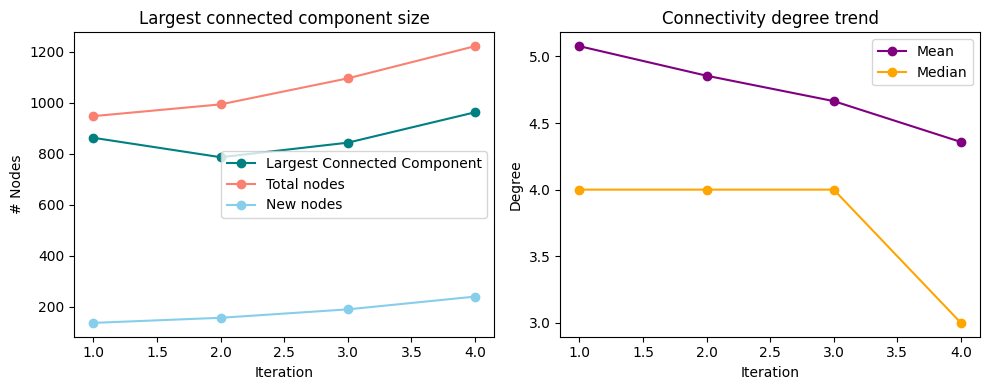

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# CC size
ax[0].plot(hist["iteration"], hist["largest_cc"], marker='o', color='teal', label='Largest Connected Component')
ax[0].plot(hist["iteration"], hist["n_nodes"], marker='o', color='salmon', label='Total nodes')
ax[0].plot(hist["iteration"], hist["n_new_outside"], marker='o', color='skyblue', label='New nodes')
ax[0].set_title("Largest connected component size")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("# Nodes")
ax[0].legend()

# Degree metrics
ax[1].plot(hist["iteration"], hist["deg_mean"], marker='o', color='purple', label='Mean')
ax[1].plot(hist["iteration"], hist["deg_median"], marker='o', color='orange', label='Median')
ax[1].set_title("Connectivity degree trend")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Degree")
ax[1].legend()
plt.tight_layout()
plt.show()

In [16]:
# --- Identify original and final nodes ---
mask_seed = (df3["cell_id"] == "djcjhfcd-1").values
original_nodes = np.where(mask_seed)[0]
final_nodes = np.array(sub_nodes)

# --- Compute outside additions ---
outside_nodes = [n for n in final_nodes if df3.iloc[n]["cell_id"] != "djcjhfcd-1"]
n_new_outside = len(outside_nodes)
frac_new_outside = n_new_outside / len(final_nodes)

print(f"Cell djcjhfcd-1:")
print(f"  Final total nodes: {len(final_nodes)}")
print(f"  Newly added (outside) nodes: {n_new_outside} ({frac_new_outside:.2%})")

# --- Gene composition of outside nodes ---
genes_outside = df3.iloc[outside_nodes]["feature_name"].value_counts().sort_values(ascending=False)
print("\nTop genes in newly added (outside) nodes:")
print(genes_outside.head(10))

Cell djcjhfcd-1:
  Final total nodes: 962
  Newly added (outside) nodes: 244 (25.36%)

Top genes in newly added (outside) nodes:
feature_name
APOE      32
CCL4      31
FCGBP     26
C3        18
FCGR1A     9
CCL3L1     8
FCGR3B     8
CD163      7
ITGB2      6
OTUD1      6
Name: count, dtype: int64



Genes pruned out from cell djcjhfcd-1: {'GNLY', 'PRF1', 'LGALS3', 'NCSTN', 'TGFB2', 'CEMIP2', 'APP', 'ARHGAP24', 'KLF2', 'GZMB', 'SLC24A3', 'IGFBP5', 'TP53', 'CNTNAP3B', 'CSRP2', 'SOX6', 'IGFBP3', 'APLNR', 'SOX4', 'CA12', 'NES', 'VEGFA', 'IDH1', 'CDK1', 'CXCL14', 'CD69', 'IKZF2', 'PTPRZ1', 'SPOCD1', 'DCX', 'ANKRD18A', 'HES6', 'IDH2', 'CD93', 'STXBP2', 'HES1', 'NDUFA9', 'IFITM3', 'NOTCH1', 'TNFAIP3', 'IL32', 'CAV1', 'LTA4H', 'UNC5B', 'BCAN'}



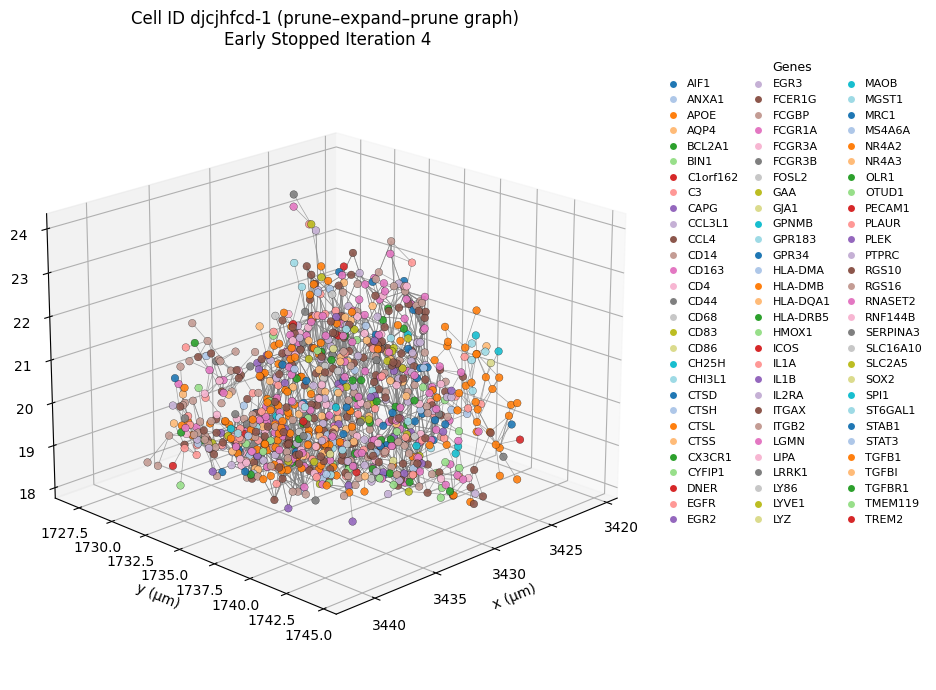

In [ ]:
# ---- Visualize pruned 3D cell graph ----
pos_all = data3.pos.numpy()
genes_all = np.array(data3.gene_name)
pos_pruned = pos_all[sub_nodes]
genes_pruned = genes_all[sub_nodes]

# --- Identify pruned genes ---
mask_nodes = (df3["cell_id"] == "djcjhfcd-1").values
genes_seed = np.array(data3.gene_name)[np.where(mask_nodes)[0]]
genes_removed = set(genes_seed) - set(genes_pruned)
print(f"\nGenes pruned out from cell djcjhfcd-1: {genes_removed}\n")

# --- Assign colors ---
unique_genes = np.unique(genes_pruned)
palette = sns.color_palette("tab20", n_colors=len(unique_genes))
gene_color_map = {g: c for g, c in zip(unique_genes, palette)}
colors = np.array([gene_color_map[g] for g in genes_pruned])

# --- 3D Plot ---
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Plot edges
for u, v in sub_edges:
    ax.plot(
        [pos_all[u, 0], pos_all[v, 0]],
        [pos_all[u, 1], pos_all[v, 1]],
        [pos_all[u, 2], pos_all[v, 2]],
        color="gray", alpha=0.7, linewidth=0.5
    )

# Plot transcripts
ax.scatter(
    pos_pruned[:, 0], pos_pruned[:, 1], pos_pruned[:, 2],
    c=colors, s=30, edgecolor="k", linewidth=0.2, alpha=0.9
)

ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_zlabel("z (µm)")
ax.set_title(f"Cell ID djcjhfcd-1 (prune–expand–prune graph) \nEarly Stopped Iteration 4", fontsize=12)
ax.view_init(elev=20, azim=45)
plt.tight_layout()

# --- Legend ---
legend_elements = [
    plt.Line2D([0], [0], marker="o", color="w",
               label=g, markerfacecolor=gene_color_map[g], markersize=6)
    for g in unique_genes
]
ax.legend(
    handles=legend_elements,
    title="Genes",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    ncol=3,                      # columns
    frameon=False,               # cleaner look
    columnspacing=0.8,           # spacing between columns
    handletextpad=0.3,           # space between marker and label
    borderaxespad=0.3,           # space between legend and plot
    fontsize=8,                  # smaller font
    title_fontsize=9
)

plt.show()